# Анализ лояльности пользователей Яндекс Афиши 

## Цели и задачи проекта 

Описание данных и немного вводных: имеются данные сервиса Яндекс Афиша, который позволяет пользователям узнавать о мероприятиях в разных городах и покупать на них билеты. Так как Яндекс Афиша сотрудничает с организаторами мероприятий и билетными операторами, которые публикуют информацию и выставляют билеты на продажу, информация об этом также будет присутствовать в будущем датасете. 
Команда маркетинга поставила следующую цель: привлекать новых пользователей, удерживать их и превращать в постоянных. Для этого нужно повысить долю клиентов, которые после одной покупки приходят снова и совершают новые. 

Моей основной задачей является анализ поведения пользователей. Для этого будет проведен исследовательский анализ данных, чтобы выяснить, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. 
В дальнейшем это позволит: 
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия. 
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата. 
- Оптимизировать маркетинговые бюджеты. 
- Повысить общий уровень удержания клиентов. 

### Содержимое проекта 

<font color='#777778'> 

Шаг 1. Загрузка данных и их предобработка 

Шаг 2. Предобработка данных 

Шаг 3. Создание профиля пользователя

Шаг 4. Исследовательский анализ данных 

Шаг 5. Общий вывод и рекомендации 

Шаг 6. Финализация проекта и публикация в Git 
    
</font> 

---

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`: данные надежно спрятаны в файле .env 

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install psycopg2-binary

In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

# Загружаем библиотеки для работы с sql файлами
import sqlalchemy

In [122]:
# загрузка значений переменных 
from dotenv import load_dotenv
import os

load_dotenv()

host = os.getenv("DB_HOST")
db = os.getenv("DB_NAME")
user = os.getenv("DB_USER")
pwd = os.getenv("DB_PASSWORD")
port = os.getenv("DB_PORT")

In [123]:
# формирование строки для подключения с помощью метода . format():
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(user, pwd, host, port, db)

In [124]:
# создание соединения, передача строки с данными для подключения функции create_engine():
engine = create_engine(connection_string)

In [125]:
# Второй этап — извлечение результатов SQL-запроса
# Запрос в переменной query  — так его удобнее редактировать. 
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT p.user_id, 
       device_type_canonical,
       order_id,
       created_dt_msk AS order_dt,
       created_ts_msk AS order_ts,
       currency_code,
       revenue,
       tickets_count,
       EXTRACT(day FROM created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev,
       p.event_id,
       event_name_code AS event_name,
       event_type_main,
       service_name,
       region_name,
       city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e on p.event_id = e.event_id
INNER JOIN afisha.city AS c on e.city_id = c.city_id
INNER JOIN afisha.regions AS r on c.region_id = r.region_id
WHERE (device_type_canonical = 'mobile' OR device_type_canonical = 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id
'''

In [126]:
# запись результата выдачи SQL-запроса в датафрейм с помощью метода pd.read_sql_query():
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [127]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [9]:
# Выводим первые строки датафрейма на экран
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Датасет содержит 15 столбцов и 290611 строк. 
Типы данных: 
- **строковые данные (object)**. Таких столбцов 8, это user_id, device_type_canonical, currency_code, event_name, event_type_main, service_name, region_name и city_name. Все являются названиями и описаниями, поэтому тип данных выбран верно.
- **Дата и время (datetime64)**. Это два поля order_dt и order_ts с данными о дате и времени заказа. 
- **числовые значения с плавающей запятой (float64)**. Также 2 поля revenue и days_since_prev.
- **Числовые значения целые (int64)**. Таких полей три: order_id, tickets_count и event_id.


Думаю, что можно понизить разрядность некоторых числовых полей, например days_since_prev и tickets_count до int16: числа в данных целые и не являются большими. 
Остальные поля вполне соответствуют своим данным, поэтому оставлю как есть. 
Названия полей также представлены в надлежащем виде и не требуют изменений. 

In [10]:
# Выводим количество пропущенных строк в датафрейме до внесения изменений
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

In [11]:
# подсчитаем в процентах, какую долю составляют пропуски от общего числа
df.isna().sum() / len(df) * 100

user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
days_since_prev          7.547202
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
dtype: float64

**Вывод:** неполные данные имеются только в поле days_since_prev: и это примерно 7.5%. Пустые значения можно заменить на 0, так как здесь отображается число дней с предудущей покупки и раз есть пустые значения, значит покупки у пользователей были единоразовые.  

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
# приверим валюты в поле currency_code
print(df['currency_code'].unique())

['rub' 'kzt']


Данная проверка нужна была, чтобы убедиться, что в данные не закрались ошибки.

In [13]:
# снизим разрядность полей days_since_prev и tickets_count к int16
df['days_since_prev'] = df['days_since_prev'].fillna(0).astype('int16')
df['tickets_count'] = df['tickets_count'].astype('int16')

In [120]:
try:
    df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
except FileNotFoundError:
    df_tenge = pd.read_csv('/Users/sofikot/Documents/python_work/ds_course/mygithub/afisha_service_analyse/data/final_tickets_tenge_df.csv')

In [121]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [16]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [17]:
# преобразуем в датасете тип обьекта для поля data и изменим название на такое же, как в первом датасете, на order_dt
df_tenge['data'] = pd.to_datetime(df_tenge['data'], errors='coerce')
df_tenge.rename(columns={'data': 'order_dt'}, inplace=True)

In [18]:
df = df.merge(
    df_tenge,
    on='order_dt',
    how='left'
) 

In [19]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,nominal,curs,cdx
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,100,18.6972,kzt
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,100,18.3419,kzt
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,100,19.6475,kzt
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,100,18.5010,kzt
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,100,19.6648,kzt


In [20]:
# добавление столбца revenue_rub и поправка цен
df['revenue_rub'] = np.where(
    df['currency_code'] == 'kzt',
    df['revenue'] / 100 * df['curs'],
    df['revenue']
)

In [21]:
# удалим ненужные поля nominal, curs и cdx из датасета
df.drop(columns=['nominal', 'curs', 'cdx'], inplace=True)

In [22]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [23]:
# подсчет количества уникальных строк
unique_order_id = df['order_id'].nunique()
print(f'Количество уникальных строк: {unique_order_id}')

Количество уникальных строк: 290611


In [24]:
# проверим есть ли явные дубликаты
df.duplicated(keep=False).sum()

np.int64(0)

Явных дубликатов в датасете нет

In [25]:
# проверим дубликаты дополнительно по всем полям, кроме order_id
df[df.duplicated(subset=['user_id', 'device_type_canonical', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'event_name', \
                         'event_type_main', 'service_name', 'region_name', 'city_name', 'revenue_rub'], keep=False)]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
11758,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.82,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,69.82
11761,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.82,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,69.82
26876,0dc525d7bacbb0d,desktop,1930705,2024-07-31,2024-07-31 13:26:11,rub,1556.05,3,0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,Лови билет!,Каменевский регион,Глиногорск,1556.05
26877,0dc525d7bacbb0d,desktop,1930763,2024-07-31,2024-07-31 13:26:11,rub,1556.05,3,0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,Лови билет!,Каменевский регион,Глиногорск,1556.05
53681,206ea45ec11d478,mobile,1935113,2024-10-29,2024-10-29 16:46:54,rub,601.69,2,0,442183,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерты,Билеты в руки,Каменевский регион,Глиногорск,601.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285379,fd4d47438ebb946,desktop,8548099,2024-06-19,2024-06-19 15:40:56,rub,989.57,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,989.57
285381,fd4d47438ebb946,desktop,8547983,2024-06-19,2024-06-19 15:40:56,rub,1319.43,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,1319.43
285382,fd4d47438ebb946,desktop,8548012,2024-06-19,2024-06-19 15:40:56,rub,1319.43,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,1319.43
285383,fd4d47438ebb946,desktop,8547867,2024-06-19,2024-06-19 15:40:56,rub,1319.43,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,1319.43


In [26]:
# подсчитаем количество дубликатов по всем полям, кроме order_id
df.duplicated(subset=['user_id', 'device_type_canonical', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', \
                      'days_since_prev', 'event_id', 'event_name', \
                      'event_type_main', 'service_name', 'region_name', 'city_name', 'revenue_rub']).sum()

np.int64(35)

Выглядит так, что некоторые поля повторяются в точности, кроме номера заказа order_id: значит было несколько попыток купить билеты, одна из которых выполнена корректно. Оставим только первые вхождения повторов, остальные будут удалены. 

In [27]:
# удалим строки с дубликатами
initial_row_count = df.shape[0]
df = df.drop_duplicates(subset=['user_id', 'device_type_canonical', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', \
                      'days_since_prev', 'event_id', 'event_name', \
                      'event_type_main', 'service_name', 'region_name', 'city_name', 'revenue_rub'], keep='first', inplace=False)
rows_deleted_count = initial_row_count - len(df)

# процент удаленных строк от общего количества
perc_deleted_rows = rows_deleted_count / initial_row_count * 100

print(f'Количество удаленных строк: {rows_deleted_count}')
print(f'Процент удаленных строк от общего количества: {perc_deleted_rows:.2f}')

Количество удаленных строк: 35
Процент удаленных строк от общего количества: 0.01


In [28]:
# проверим снова количество дубликатов по всем полям, кроме order_id
df.duplicated(subset=['user_id', 'device_type_canonical', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', \
                      'days_since_prev', 'event_id', 'event_name', \
                      'event_type_main', 'service_name', 'region_name', 'city_name', 'revenue_rub']).sum()

np.int64(0)

Вывод: повторов больше нет, удалено 35 строк, что составляет 0,12% от общего количества. 

In [29]:
# выведем уникальные значения для поля device_type_canonical и их количество
print(sorted(df['device_type_canonical'].unique()))
print(f"Количество девайсов до изменений: {df['device_type_canonical'].nunique()}")

['desktop', 'mobile']
Количество девайсов до изменений: 2


In [30]:
# выведем количество заказов с разных устройств
df['device_type_canonical'].value_counts()

device_type_canonical
mobile     232465
desktop     58111
Name: count, dtype: int64

In [31]:
# выведем уникальные значения для поля event_type_main и их количество
print(sorted(df['event_type_main'].unique()))
print(f"Количество мероприятий: {df['event_type_main'].nunique()}")

['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
Количество мероприятий: 7


In [32]:
# выведем количество заказов для каждого типа мероприятия
df['event_type_main'].value_counts()

event_type_main
концерты    115268
театр        67312
другое       65855
спорт        21906
стендап      13393
выставки      4853
ёлки          1989
Name: count, dtype: int64

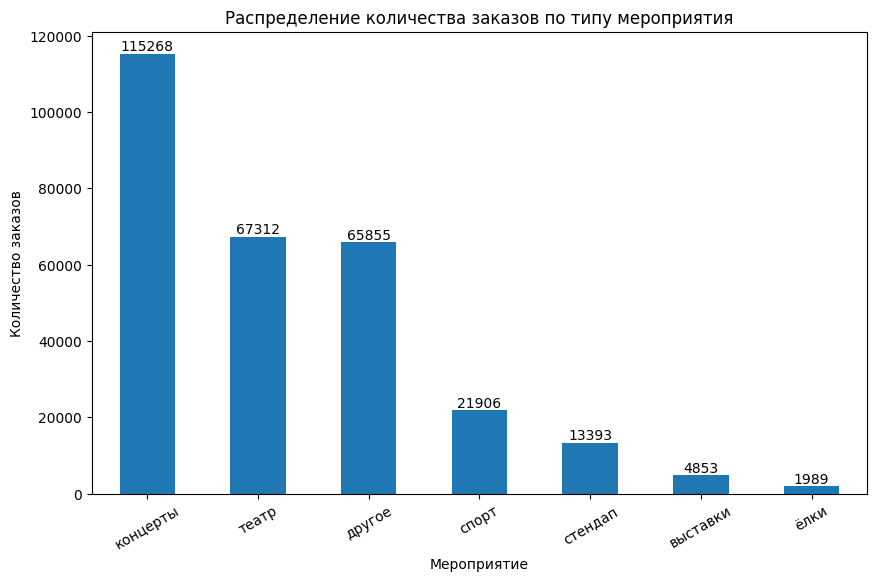

In [33]:
# построим график столбчатой диаграммы
grouped = df['event_type_main'].value_counts()

ax = grouped.plot(
    kind='bar',
    title='Распределение количества заказов по типу мероприятия',
    ylabel='Количество заказов',
    xlabel='Мероприятие',
    rot=30,
    figsize=(10, 6))

for i, value in enumerate(grouped.values):
    ax.text(i, value, value, ha='center', va='bottom')


plt.show()

In [34]:
# выведем уникальные значения для поля service_name и их количество
print(sorted(df['service_name'].unique()))
print(f"Количество провайдеров билетов: {df['service_name'].nunique()}")

['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']
Количество провайдеров билетов: 36


In [35]:
# выведем количество значений в азвисимости от сервиса
df['service_name'].value_counts()

service_name
Билеты без проблем        63504
Лови билет!               41119
Билеты в руки             40336
Мой билет                 34837
Облачко                   26642
Лучшие билеты             17772
Весь в билетах            16848
Прачечная                 10273
Край билетов               6207
Тебе билет!                5227
Яблоко                     5039
Дом культуры               4502
За билетом!                2864
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2002
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

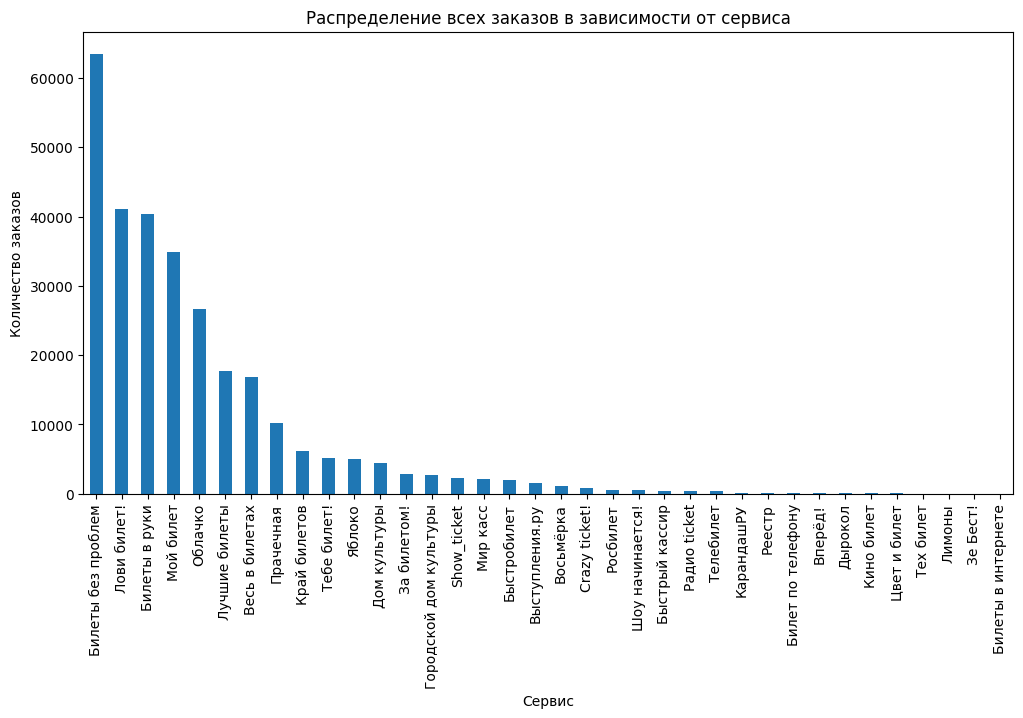

In [36]:
# построим график столбчатой диаграммы распределения заказов в зависимости от сервиса
grouped = df['service_name'].value_counts()

ax = grouped.plot(
    kind='bar',
    title='Распределение всех заказов в зависимости от сервиса',
    ylabel='Количество заказов',
    xlabel='Сервис',
    figsize=(12, 6))

plt.show()

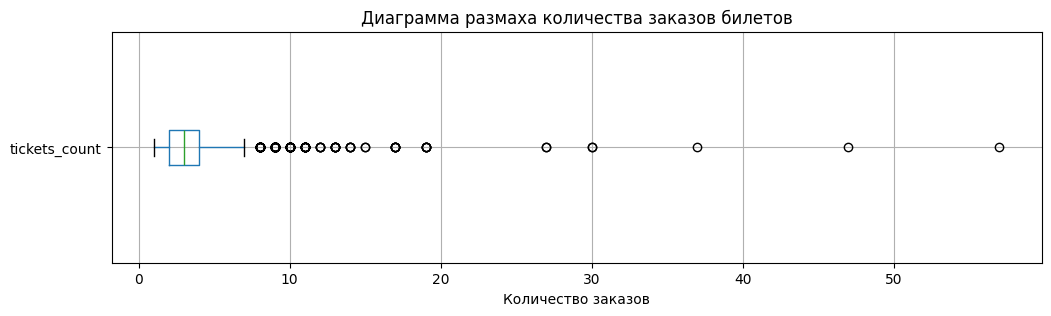

In [37]:
# tickets_count
# 
boxplot = df.boxplot( column='tickets_count', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(12, 3)) 
boxplot.set_title('Диаграмма размаха количества заказов билетов') 
boxplot.set_xlabel('Количество заказов') 
# Выводим график 
plt.show()

In [38]:
# выводим результат describe() до фильтрации даннных для поля revenue_rub
print(df['revenue_rub'].describe())

count    290576.000000
mean        555.588121
std         875.526351
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64


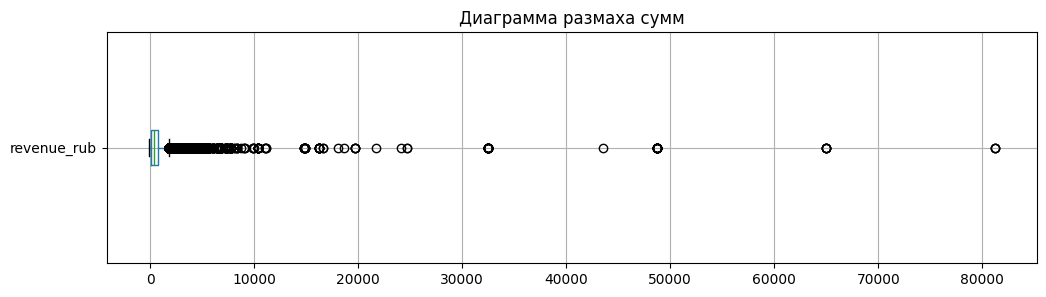

In [39]:
# revenue_rub диаграмма размаха до изменений
boxplot = df.boxplot( column='revenue_rub', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(12, 3)) 
boxplot.set_title('Диаграмма размаха сумм') 
 
# Выводим график 
plt.show()

In [40]:
# находим 99й перцентиль
outliers = df['revenue_rub'].quantile(0.99)

# отбираем данные, оставляя значения меньше найденного порога выбросов
new_df = df.loc[df['revenue_rub'] < outliers]

# выводим результат describe() после фильтрации даннных
print(new_df['revenue_rub'].describe())

count    287569.000000
mean        516.705308
std         509.354310
min         -90.760000
25%         111.690000
50%         343.620000
75%         787.710000
max        2627.000000
Name: revenue_rub, dtype: float64


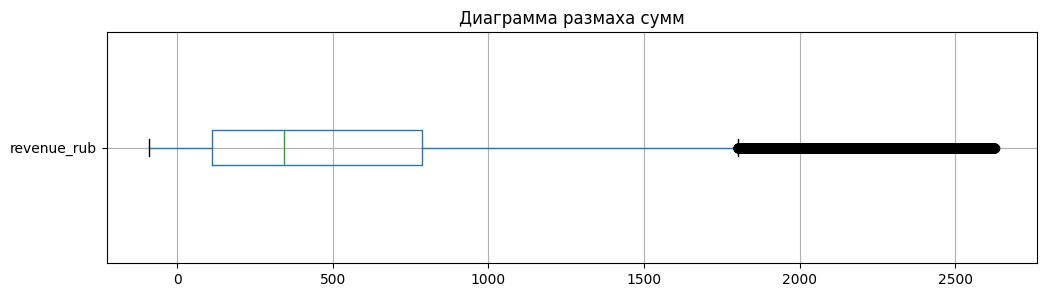

In [41]:
# revenue_rub диаграмма размаха после изменений
boxplot = new_df.boxplot( column='revenue_rub', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(12, 3) ) 
boxplot.set_title('Диаграмма размаха сумм') 
 
# Выводим график 
plt.show()

In [42]:
# проверим количество отрицательных значений в поле revenue_rub
(df['revenue_rub'] < 0).sum()

np.int64(381)

**Вывод после предобработки данных:** 

Пропуски: пропущенные значения были обнаружены только в столбце `days_since_prev` и заменены на нули. 
Выполнено преобразование типов данных для полей `tickets_count`, `days_since_prev` и добавлено поле `revenue_rub`. 

По результатам диаграмм размаха для полей `revenue_rub` и `tickets_count` можно сказать следующее: Отрицательных и нулевых значений в поле `tickets_count` не обнаружено, аномальные есть и это похоже на единичные массовые заказы, например для компании, школы, какой-то группы.
В поле `revenue_rub` есть отрицательные значения в количестве 381, где минимальное равно -90.76. Это похоже на специальные акции, комиссии, возвраты, где происходит перерасчет стоимости после покупки, и такие значения показаны как возвраты. 

Значения выше 99 перцентиля отфильтрованы и в результате было убрано для диаграммы 3007 строк, это около 1,03%

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [43]:
# сортировка данных по времени совершения заказа
df = df.sort_values(by='order_ts')

In [44]:
# группировка по каждому пользователю
user_profile = df.groupby('user_id').agg(
    first_order_date=('order_ts', 'min'), # первый заказ
    last_order_date=('order_ts', 'max'), # последний
    first_device=('device_type_canonical', 'first'), # устройство, с которого был сделан первый заказ
    first_region=('region_name', 'first'), # регион, в котором был сделан первый заказ
    first_service=('service_name', 'first'), # билетный партнер, к которому обращались при первом заказе
    first_event_type=('event_type_main', 'first'), # жанр первого посещенного мероприятия
    orders_count=('order_id', 'count'), # общее количество заказов
    avg_revenue_rub=('revenue_rub', 'mean'), # средняя выручка с одного заказа в рублях
    avg_tickets=('tickets_count', 'mean'), #среднее количество билетов в заказе
    avg_days_between=('days_since_prev', 'mean') #среднее время между заказами
)

# сброс индекса
user_profile = user_profile.reset_index()

In [45]:
# добавьте два бинарных признака: 
# is_two совершил ли пользователь 2 и более заказа
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)

# is_five совершил ли пользователь 5 и более заказов
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

In [46]:
user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0.0,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37.5,1,0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34.0,1,0
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0.0,0,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [47]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21933 non-null  object        
 1   first_order_date  21933 non-null  datetime64[ns]
 2   last_order_date   21933 non-null  datetime64[ns]
 3   first_device      21933 non-null  object        
 4   first_region      21933 non-null  object        
 5   first_service     21933 non-null  object        
 6   first_event_type  21933 non-null  object        
 7   orders_count      21933 non-null  int64         
 8   avg_revenue_rub   21933 non-null  float64       
 9   avg_tickets       21933 non-null  float64       
 10  avg_days_between  21933 non-null  float64       
 11  is_two            21933 non-null  int64         
 12  is_five           21933 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(5)
memory usage: 2.2+ MB


In [48]:
# общее число пользователей в выборке
all_users = user_profile.shape[0]

# средняя выручка с одного заказа
avg_order_sum = round(user_profile['avg_revenue_rub'].mean(), 2)

# доля пользователей, совершивших 2 и более заказа
perc_two_orders = round(user_profile['is_two'].sum() / len(df) * 100, 2)

# доля пользователей, совершивших 5 и более заказов
perc_five_orders = round(user_profile['is_five'].sum() / len(df) * 100, 2)


print(f'общее число пользователей в выборке: {all_users}')
print(f'средняя выручка с одного заказа: {avg_order_sum}')
print(f'доля пользователей, совершивших 2 и более заказа: {perc_two_orders}')
print(f'доля пользователей, совершивших 5 и более заказов: {perc_five_orders}')

общее число пользователей в выборке: 21933
средняя выручка с одного заказа: 574.02
доля пользователей, совершивших 2 и более заказа: 4.67
доля пользователей, совершивших 5 и более заказов: 2.2


In [49]:
user_profile[['orders_count','avg_tickets','avg_days_between']].describe()

,orders_count,avg_tickets,avg_days_between
count,21933.000000,21933.000000,21933.000000
mean,13.248347,2.755986,6.504656
std,122.458042,0.920732,10.929052
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000
50%,2.000000,2.764151,0.000000
75%,5.000000,3.125000,9.416667
max,10251.000000,12.000000,74.000000


In [50]:
top_orders_count = user_profile.sort_values(by='orders_count', ascending=False).head(10)
print(top_orders_count[['first_service', 'orders_count']])

            first_service  orders_count
985         Билеты в руки         10251
2061              Облачко          4368
11114       Билеты в руки          4053
5432            Мой билет          3825
10849  Билеты без проблем          3745
2338               Реестр          3538
6801               Реестр          3413
14816         Лови билет!          3275
15555         Лови билет!          3163
17698         Лови билет!          3070


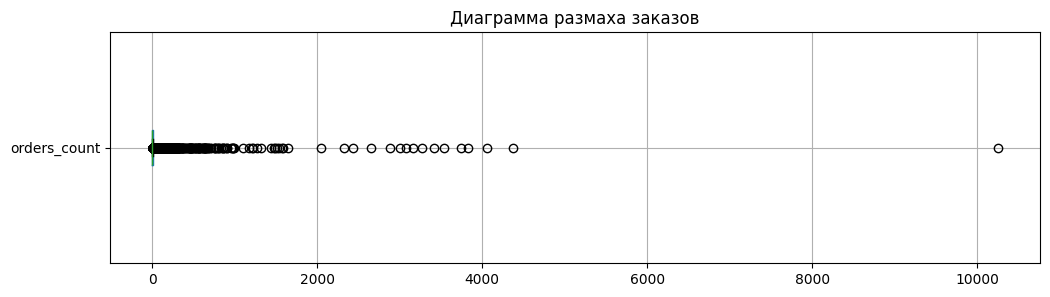

In [51]:
# orders_count диаграмма размаха
boxplot = user_profile.boxplot( column='orders_count', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(12, 3) ) 
boxplot.set_title('Диаграмма размаха заказов') 

# Выводим график 
plt.show()

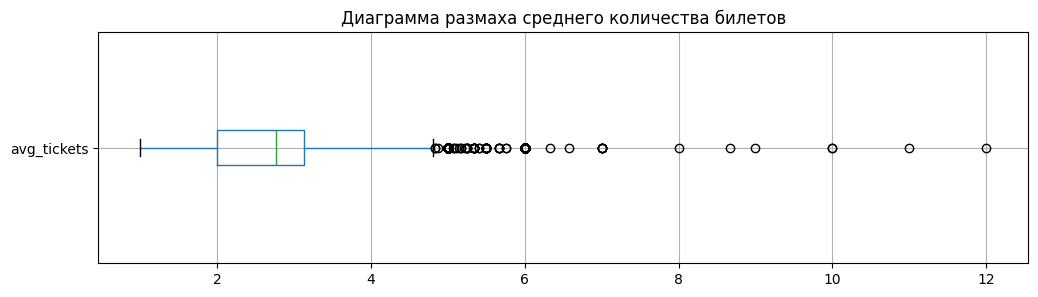

In [52]:
# avg_tickets диаграмма размаха
boxplot = user_profile.boxplot( column='avg_tickets', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(12, 3) ) 
boxplot.set_title('Диаграмма размаха среднего количества билетов') 

# Выводим график 
plt.show()

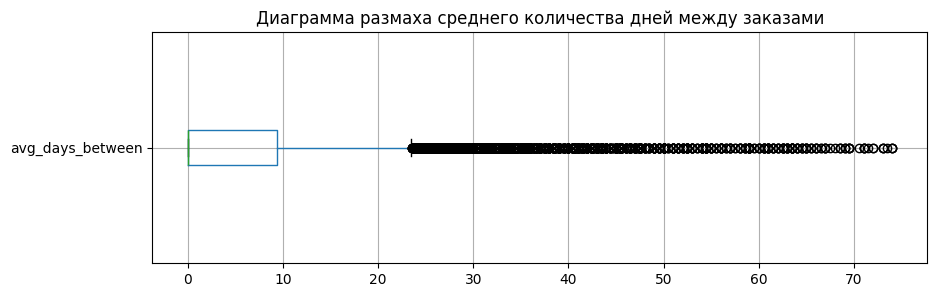

In [53]:
# avg_days_between диаграмма размаха
boxplot = user_profile.boxplot( column='avg_days_between', 
                      vert=False, 
                      grid=True, 
                      showfliers=True, 
                      figsize=(10, 3) ) 
boxplot.set_title('Диаграмма размаха среднего количества дней между заказами') 

# Выводим график 
plt.show()

**Вывод:** 
1) судя по диаграмме размаха количества заказов для каждого пользователя есть один сильно выдающийся, где количество заказов равно 10251. Думаю, что для более обьективного анализа данных строку с этим показателем можно убрать из выборки.
2) диаграмма размаха среднего количества билетов показывает вариацию от 2 до 12 билетов - вполне вероятные данные, поэтому все оставлю как есть. 
3) в диаграмме размаха касательно среднего количества дней между заказами основная масса показателей лежит между 0 и 10 днями, а максимальное количество дней 74. В целом вполне вероятные данные, поэтому также оставлю эти данные.

Общее число пользователей в выборке: 21933 

Средняя выручка с одного заказа: 574.02 

Доля пользователей, совершивших 2 и более заказа: 4.67% 

Доля пользователей, совершивших 5 и более заказов: 2.2% 

In [54]:
# удаление строку с максимальным значением количества билетов
user_profile.drop(user_profile[user_profile['orders_count'] == 10251].index, inplace=True)

In [55]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21932 entries, 0 to 21932
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21932 non-null  object        
 1   first_order_date  21932 non-null  datetime64[ns]
 2   last_order_date   21932 non-null  datetime64[ns]
 3   first_device      21932 non-null  object        
 4   first_region      21932 non-null  object        
 5   first_service     21932 non-null  object        
 6   first_event_type  21932 non-null  object        
 7   orders_count      21932 non-null  int64         
 8   avg_revenue_rub   21932 non-null  float64       
 9   avg_tickets       21932 non-null  float64       
 10  avg_days_between  21932 non-null  float64       
 11  is_two            21932 non-null  int64         
 12  is_five           21932 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(5)
memory usage: 2.3+ MB


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [56]:
# выведем первые строки датасета для наглядности и последующих операций
user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0.0,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37.5,1,0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34.0,1,0
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0.0,0,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8.0,1,0


                  user_id   perc
first_event_type                
концерты             9700  44.23
другое               5489  25.03
театр                4312  19.66
стендап              1118   5.10
спорт                 804   3.67
выставки              414   1.89
ёлки                   95   0.43


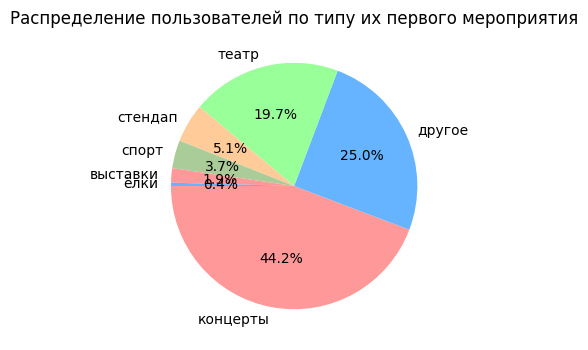

In [57]:
# группировка пользователей с помощью pivot_table по типу их первого мероприятия
pivot_event_type = pd.pivot_table(
    user_profile,
    index=['first_event_type'],
    values='user_id',
    aggfunc='count'
).sort_values(by='user_id', ascending=False)

pivot_event_type['perc'] = (
    pivot_event_type['user_id']
    / pivot_event_type['user_id'].sum()
    * 100
).round(2)

print(pivot_event_type)

# построим круговую диаграмму
df_event_type = pivot_event_type['user_id']

ax = df_event_type.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Распределение пользователей по типу их первого мероприятия',
    ylabel='',
    startangle=180, 
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#aacc99'],
    figsize=(4, 4)
)

**Вывод:** 
Большая часть заказов пользователей приходится на концерты, театр и другое (точно не названное, видимо ряд весьма различных мероприятий) и это около 90% от всего. 
Равномерного распределения здесь нет. 

              user_id  perc
first_device               
mobile          18160  82.8
desktop          3772  17.2


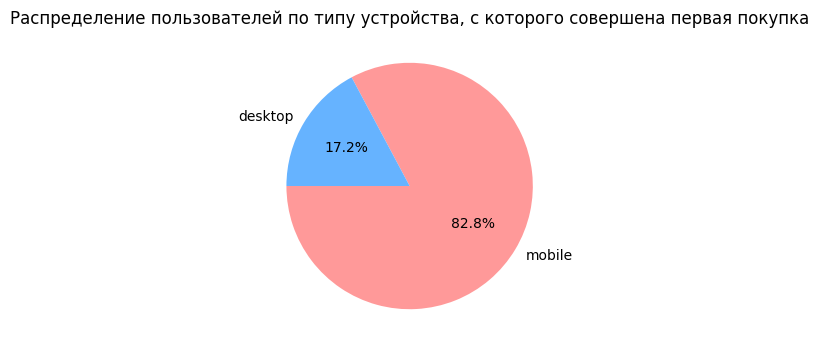

In [58]:
# группировка пользователей с помощью pivot_table по типу устройства, с которого совершена первая покупка
pivot_first_device = pd.pivot_table(
    user_profile,
    index='first_device',
    values='user_id',
    aggfunc='count'
).sort_values(by='user_id', ascending=False)

pivot_first_device['perc'] = (
    pivot_first_device['user_id']
    / pivot_first_device['user_id'].sum()
    * 100
).round(2)

print(pivot_first_device)

# построим круговую диаграмму
df_first_device = pivot_first_device['user_id']

ax = df_first_device.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Распределение пользователей по типу устройства, с которого совершена первая покупка',
    ylabel='',
    startangle=180, 
    colors=['#ff9999','#66b3ff'],
    figsize=(4, 4)
)

**Вывод:** 
более чем в 82% случаев пользователи делают заказ с мобильного телефона, заказы с ноутбука/компьютера занимают менее 1/5 частьи всех заказов.  

In [59]:
# группировка пользователей с помощью pivot_table по региону проведения мероприятия из первого заказа;
pivot_first_region = pd.pivot_table(
    user_profile,
    index='first_region',
    values='user_id',
    aggfunc='count'
).sort_values(by='user_id', ascending=False)

pivot_first_region['perc'] = (
    pivot_first_region['user_id']
    / pivot_first_region['user_id'].sum()
    * 100
).round(2)

print(pivot_first_region)


                          user_id   perc
first_region                            
Каменевский регион           7209  32.87
Североярская область         3794  17.30
Широковская область          1244   5.67
Озернинский край              679   3.10
Малиновоярский округ          536   2.44
...                           ...    ...
Залесский край                  2   0.01
Тихогорская область             2   0.01
Верхозёрский край               1   0.00
Сосноводолинская область        1   0.00
Яснопольский округ              1   0.00

[81 rows x 2 columns]


**Вывод:** 
Большая часть заказов пользователей приходится на следующие регионы: Каменевский регион 32.87%, Североярская область 17.30%, Широковская область 5.67%, Озернинский край 3.10% и Малиновоярский округ 2.44%. 
Вполне вероятно, что в этих регионах региональными центрами являются большие города и в целом они густо населенны, где часто проходят различные мероприятия. 

Так как регионов много, а именно 36 не добавляла никакой визуализациии. 

In [60]:
# группировка пользователей с помощью pivot_table по билетному оператору, продавшему билеты на первый заказ
pivot_first_service = pd.pivot_table(
    user_profile,
    index='first_service',
    values='user_id',
    aggfunc='count'
).sort_values(by='user_id', ascending=False)

pivot_first_service['perc'] = (
    pivot_first_service['user_id']
    / pivot_first_service['user_id'].sum()
    * 100
).round(2)

print(pivot_first_service)

                        user_id   perc
first_service                         
Билеты без проблем         5233  23.86
Мой билет                  3022  13.78
Лови билет!                2853  13.01
Билеты в руки              2586  11.79
Облачко                    2195  10.01
Весь в билетах             1320   6.02
Лучшие билеты              1186   5.41
Прачечная                   592   2.70
Край билетов                462   2.11
Дом культуры                355   1.62
Яблоко                      320   1.46
Тебе билет!                 311   1.42
Городской дом культуры      220   1.00
Мир касс                    207   0.94
За билетом!                 205   0.93
Show_ticket                 171   0.78
Быстробилет                 163   0.74
Выступления.ру               98   0.45
Восьмёрка                    87   0.40
Быстрый кассир               59   0.27
Росбилет                     52   0.24
Crazy ticket!                45   0.21
Реестр                       39   0.18
Радио ticket             

**Вывод:** 
Здесь также нет равномерного распределения всех заказов в разрезе провайдера билетов: ~70% пользователей делают покупки у одного из пяти наиболее популярных сервисов - `Билеты без проблем` 23.86%, `Мой билет` 13.78%, `Лови билет!` 13.01%, `Билеты в руки` 11.79% и `Облачко` 10.01%. 
Наличие слова "билет" в названии сервиса явно помогает при покупках этих самых билетов. И хотя сервис "облачко" такого не имеет, возможно была хорошая реклама при создании. 

Здесь также визуализация данных не имеет смысла, поэтому только числовые данные. 

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [61]:
# функция вычисления вовзращений для каждого из необхоимых сегментов
def return_segment_users(df, segment_column, top_10=None):
    # df = user_profile
    # segment_column = название сегмента
    # top_10 = оставить только топ 10 сегментов по размеру
    result = (
        df
        .groupby(segment_column)
        .agg(
            users_count=('user_id', 'count'),
            two_plus_orders=('is_two', 'mean'))
        .reset_index()
    )

    # подсчитаем долю
    result['return_perc'] = (result['two_plus_orders'] * 100).round(2)

    # сортируем по количеству пользователей
    result = result.sort_values('users_count', ascending=False)

    # топ10 сегментов
    if top_10 is not None:
        result = result.head(10)

    return result

In [62]:
# возвращения по типу мероприятия
return_event = return_segment_users(
    user_profile,
    'first_event_type')
return_event

,first_event_type,users_count,two_plus_orders,return_perc
2,концерты,9700,0.623918,62.39
1,другое,5489,0.601202,60.12
5,театр,4312,0.638915,63.89
4,стендап,1118,0.610018,61.00
3,спорт,804,0.562189,56.22
0,выставки,414,0.640097,64.01
6,ёлки,95,0.547368,54.74


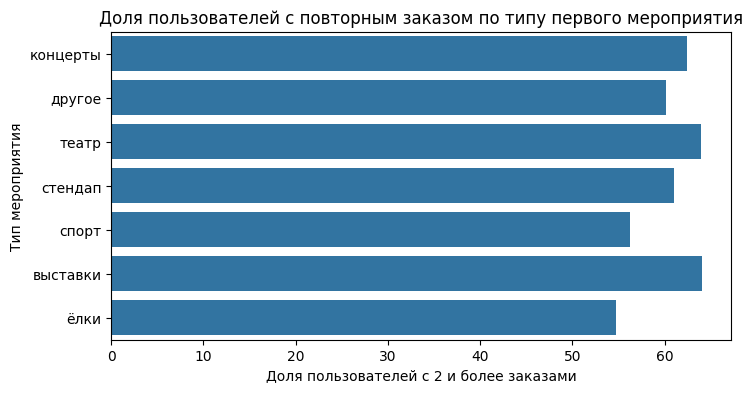

In [63]:
# построим график столбчатой диаграммы
plt.figure(figsize=(8, 4))

sns.barplot(
    data=return_event,
    x='return_perc',
    y='first_event_type')

plt.title('Доля пользователей с повторным заказом по типу первого мероприятия')
plt.xlabel('Доля пользователей с 2 и более заказами')
plt.ylabel('Тип мероприятия')

plt.show()

**Вывод:** 
В среднем пользователи выбирают те же меропритятия более чем в половине случаев, однако лидируют в этом сегменте `выставки`, `театры` и `концерты`, поэтому можно сказать, что они являются успешными "точками входа". 

In [64]:
# возвращения по типу device
return_device = return_segment_users(
    user_profile,
    'first_device')

return_device

,first_device,users_count,two_plus_orders,return_perc
1,mobile,18160,0.613161,61.32
0,desktop,3772,0.642365,64.24


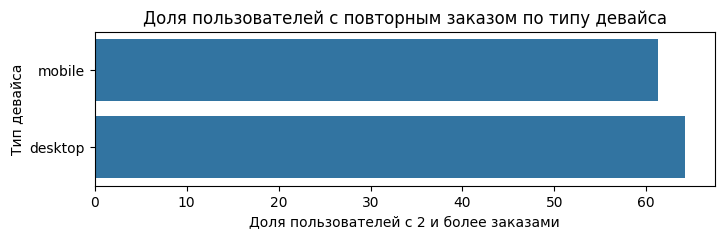

In [65]:
# построим график столбчатой диаграммы
plt.figure(figsize=(8, 2))

sns.barplot(
    data=return_device,
    x='return_perc',
    y='first_device')

plt.title('Доля пользователей с повторным заказом по типу девайса')
plt.xlabel('Доля пользователей с 2 и более заказами')
plt.ylabel('Тип девайса')

plt.show()

**Вывод:** 
Пользователи, покупающие билеты на мероприятия с десктопа чаще покупают таким же образом, в сравнении с мобильным телефоном  -  что в целом понятно: на "большом" экране часто удобнее и информативнее выбирать и бронировать билеты. Большое значение на возврат пользователей этот показатель не оказывает. 


In [66]:
# возвращения по типу region
return_region = return_segment_users(
    user_profile,
    'first_region',
    10)

return_region

,first_region,users_count,two_plus_orders,return_perc
23,Каменевский регион,7209,0.628520,62.85
60,Североярская область,3794,0.642330,64.23
77,Широковская область,1244,0.651125,65.11
45,Озернинский край,679,0.552283,55.23
41,Малиновоярский округ,536,0.565299,56.53
76,Шанырский регион,509,0.685658,68.57
74,Травяная область,494,0.619433,61.94
57,Светополянский округ,469,0.663113,66.31
52,Речиновская область,442,0.640271,64.03
78,Яблоневская область,419,0.599045,59.90


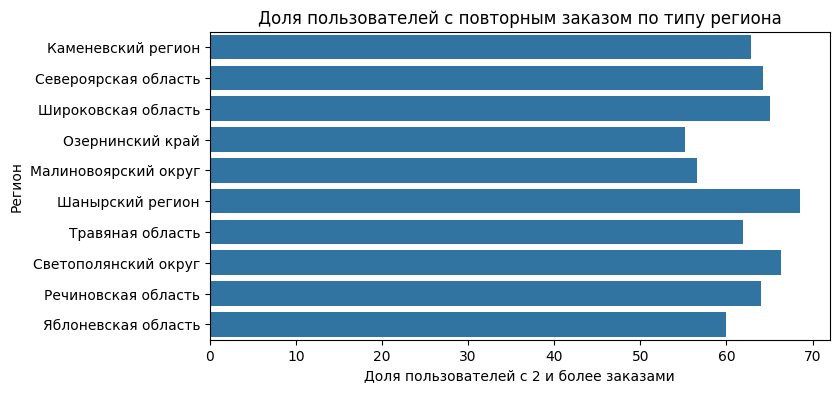

In [67]:
# построим график столбчатой диаграммы
plt.figure(figsize=(8, 4))

sns.barplot(
    data=return_region,
    x='return_perc',
    y='first_region')

plt.title('Доля пользователей с повторным заказом по типу региона')
plt.xlabel('Доля пользователей с 2 и более заказами')
plt.ylabel('Регион')

plt.show()

**Вывод:** 
Возвращение пользователей из таких регионов, как: `Шанырский`, `Светополянский`, `Речиновская область`, `Широковская область`, `Североярская область` и `Каменевский` выше среднего значения, а также эти регионы имеют наибольшее количество пользователей (особенно `Североярская область` и `Каменевский регион`). Думаю, что эти регионы можно считать наиболее успешными точками входа. 


In [68]:
# возвращения по типу service
return_service = return_segment_users(
    user_profile,
    'first_service',
    10)

return_service

,first_service,users_count,two_plus_orders,return_perc
3,Билеты без проблем,5233,0.608064,60.81
22,Мой билет,3022,0.613832,61.38
19,Лови билет!,2853,0.616193,61.62
4,Билеты в руки,2586,0.631864,63.19
23,Облачко,2195,0.616856,61.69
7,Весь в билетах,1320,0.636364,63.64
20,Лучшие билеты,1186,0.613828,61.38
24,Прачечная,592,0.630068,63.01
17,Край билетов,462,0.655844,65.58
12,Дом культуры,355,0.647887,64.79


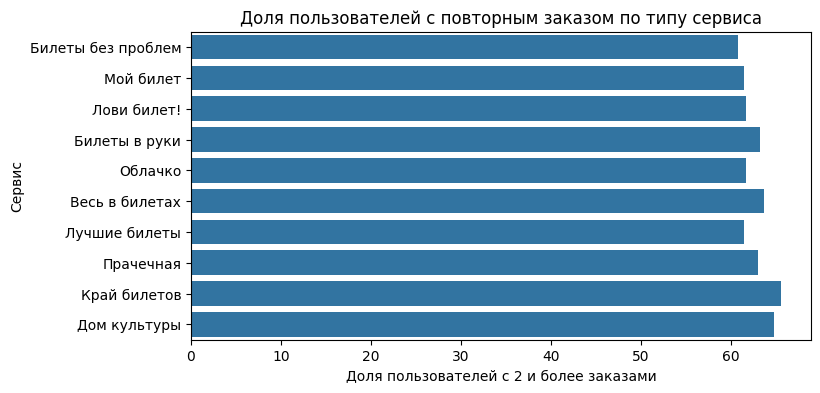

In [69]:
# построим график столбчатой диаграммы
plt.figure(figsize=(8, 4))

sns.barplot(
    data=return_service,
    x='return_perc',
    y='first_service')

plt.title('Доля пользователей с повторным заказом по типу сервиса')
plt.xlabel('Доля пользователей с 2 и более заказами')
plt.ylabel('Сервис')

plt.show()

**Вывод:** 
С учетом того, что отобраны топ 10 сервисов - выводы можно считать достоверными и достаточно стабильными. 
Сервисы с возвратом пользователей выше среднего: `Край билетов`, `Дом культуры`, `Весь в билетах`, `Билеты в руки` и `Прачечная`. 
Остальные сервисы в рамках среднего значения, но немного отстает самый часто используемый сервис - `Билеты без проблем`. 
По всей видимости, влияние сервиса на возврат пользователей не играет значительныю роль. 

In [70]:
# среднее значение по полю 2 и более заказов вне зависимости от сегментов
all_return_rate = user_profile['is_two'].mean() * 100
round(all_return_rate, 2)

np.float64(61.82)

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [71]:
# Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: 
# пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, 
# чем пользователи, оформившие свой первый заказ на концерты.


In [72]:
# sport
sport_users = user_profile[user_profile['first_event_type'] == 'спорт']

sport_return_count = (
    sport_users['is_two']
    .value_counts()
    .reset_index())

sport_return_count.columns = ['is_returned', 'users_count']

sport_return_count['perc'] = (sport_return_count['users_count'] / sport_return_count['users_count'].sum() * 100).round(2)

sport_return_count['is_returned'] = sport_return_count['is_returned'].map({
    1: 'Сделали повторный заказ',
    0: 'Сделали только один заказ'
})

sport_return_count

,is_returned,users_count,perc
0,Сделали повторный заказ,452,56.22
1,Сделали только один заказ,352,43.78


In [73]:
# концерты
concert_users = user_profile[user_profile['first_event_type'] == 'концерты']

concert_return_count = (
    concert_users['is_two']
    .value_counts()
    .reset_index())

concert_return_count.columns = ['is_returned', 'users_count']
concert_return_count['perc'] = (concert_return_count['users_count'] / concert_return_count['users_count'].sum() * 100).round(2)

concert_return_count['is_returned'] = concert_return_count['is_returned'].map({
    1: 'Сделали повторный заказ',
    0: 'Сделали только один заказ'
})
concert_return_count

,is_returned,users_count,perc
0,Сделали повторный заказ,6052,62.39
1,Сделали только один заказ,3648,37.61


**Проверка первой гипотезы:** 
Судя по количеству и процентному соотношению пользователей, вероятность того, что пользователи вернутся на площадку для заказа билета значительно выше у тех, кто ходит на концерты, а не спортивные мероприятия. Поэтому данная гипотеза неверна, данные говорят об обратном. 

In [74]:
# - Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, 
# выше доля повторных заказов, чем в менее активных регионах.

In [75]:
# регионы
region_users = (
    user_profile
    .groupby('first_region')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')))
    #.sort_values(by='users_count', ascending=False))

region_users['return_rate'] = (region_users['return_rate'] * 100).round(2)

# подсчитаем медиану
median_users = region_users['users_count'].median()

region_users['region_active'] = np.where(region_users['users_count'] >= median_users,'активные регионы', 'менее активные регионы')

# вывод активности регионов
activity_comparison = (
    region_users
    .groupby('region_active')
    .agg(
        regions_count=('region_active', 'count'),
        avg_return_perc=('return_rate', 'mean'),
        median_return_perc=('return_rate', 'median'))
    .reset_index())

activity_comparison
#region_users

,region_active,regions_count,avg_return_perc,median_return_perc
0,активные регионы,42,59.302381,59.42
1,менее активные регионы,39,52.802308,54.29


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [76]:
# пользователи с одним заказом
one_order_users = user_profile[user_profile['orders_count'] == 1]

# пользователи с двумя и более заказами
two_more_orders_users = user_profile[user_profile['orders_count'] >= 2]

In [77]:
# посмотрим колиество пользователей по группам
print(f'пользователи с одним заказом: {len(one_order_users)}')
print(f'пользователи с двумя и более заказами: {len(two_more_orders_users)}')

пользователи с одним заказом: 8374
пользователи с двумя и более заказами: 13558


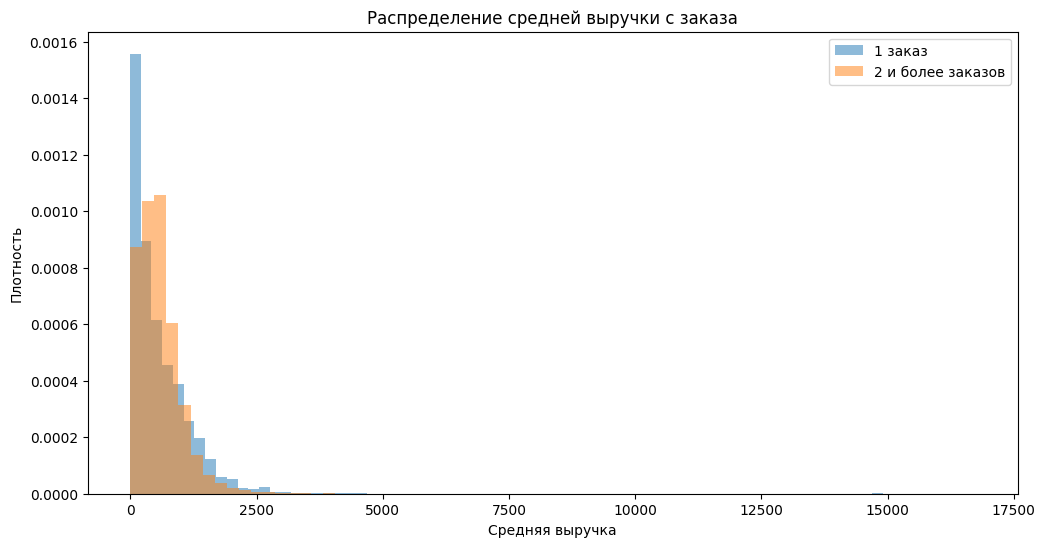

In [78]:
# построим гистограмму
plt.figure(figsize=(12,6))

plt.hist(one_order_users['avg_revenue_rub'], bins=70, alpha=0.5, density=True, label='1 заказ')
plt.hist(two_more_orders_users['avg_revenue_rub'], bins=70, alpha=0.5, density=True, label='2 и более заказов')

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность')
plt.legend()

plt.show()

**Ответы на вопросы:** 
1) В каких диапазонах средней выручки концентрируются пользователи из каждой группы? 
Диапазон средней выручки расположен между 0 и 2500 - основная масса всех заказов, вне зависимости от их количества. 

2) Есть ли различия между группами? 
Судя по гистаграмме выше, очень часто единичные заказы выполняются в случае низкой стоимости заказа, и уменьшаются значительно при увеличении стоимости.
Повторные заказы выполняются при более высоких тратах, и плотность их довольна высокая (хотя по ценам это в промежутке от 0 до ~1200 руб, судя по графику).

Вывод: глобальных различий здесь нет, видимо размер среднего чека не самый значительный фактор возврата пользователей на сервис. 
При этом, количество пользователей с одним заказом: 8374. 
Количество пользователей с двумя и более заказами: 13559. 

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [79]:
# пользователи, совершившие 2-4 заказа
users_2_4_orders = user_profile[(user_profile['orders_count'] >= 2) & (user_profile['orders_count'] <= 4)]

# пользователи, совершившие 5 и более заказов
users_5_plus_orders = user_profile[user_profile['orders_count'] >= 5]

In [80]:
# посмотрим колиество пользователей по группам
print(f'пользователи с 2-4 заказами: {len(users_2_4_orders)}')
print(f'пользователи с 5 и более заказами: {len(users_5_plus_orders)}')

пользователи с 2-4 заказами: 7161
пользователи с 5 и более заказами: 6397


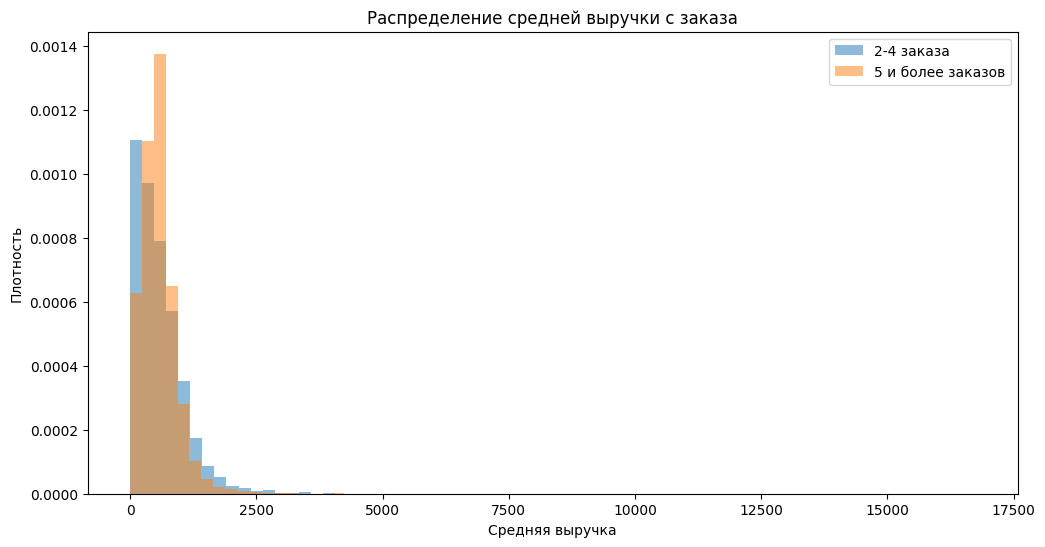

In [81]:
# построим гистограмму
plt.figure(figsize=(12,6))

plt.hist(users_2_4_orders['avg_revenue_rub'], bins=70, alpha=0.5, density=True, label='2-4 заказа')
plt.hist(users_5_plus_orders['avg_revenue_rub'], bins=70, alpha=0.5, density=True, label='5 и более заказов')

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность')
plt.legend()

plt.show()

**Вывод:**  в данном случае, распределение средней выручки с заказа еще менее зависит от количества раз, которые пользователи вернулись на сервис для поупки билетов: средняя выручка так же в пределах от 0 до 2500, где наибольшая плотность наблюдается при более дешевых заказах. 

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [82]:
user_profile.head(10)

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0.000000,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37.500000,1,0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34.000000,1,0
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0.000000,0,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8.000000,1,0
5,000cf0659a9f40f,2024-06-20 10:35:26,2024-06-21 04:36:17,mobile,Широковская область,Лови билет!,концерты,13,1175.808462,3.307692,0.076923,1,1
6,00147c9209d45d3,2024-06-25 23:26:58,2024-06-25 23:28:52,mobile,Каменевский регион,Облачко,концерты,2,352.945000,1.500000,0.000000,1,0
7,0018ecd8a38a51b,2024-07-25 20:38:57,2024-07-25 20:38:57,mobile,Медовская область,Билеты без проблем,спорт,1,0.000000,3.000000,0.000000,0,0
8,00199a573901564,2024-06-17 22:58:15,2024-06-17 22:58:15,mobile,Каменевский регион,Билеты без проблем,концерты,1,588.120000,4.000000,0.000000,0,0
9,001e7037d013f0f,2024-07-04 08:06:44,2024-09-29 22:58:14,mobile,Златопольский округ,Мой билет,другое,3,326.623333,1.333333,29.000000,1,0


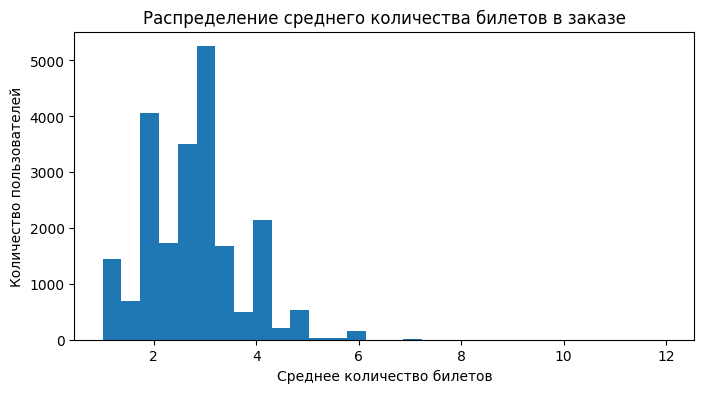

In [83]:
plt.figure(figsize=(8,4))

plt.hist(user_profile['avg_tickets'], bins=30)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')

plt.show()

Судя по графику, основное количество заказываемых билетов от 1 до 6, где чаще всего берут 2-3 билета, так как людт идут парой, семьей на мероприятия. 

In [84]:
# разобьем на сегменты все заказы и добавим в датасет столбец
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets'],
    bins=[1, 2, 3, 5, user_profile['avg_tickets'].max()],
    labels=[
        '1–2 билета',
        '2–3 билета',
        '3–5 билетов',
        '5+ билетов'
    ],
    include_lowest=True)

In [85]:
# группировка данных, общее число и доля
tickets_segments = (
    user_profile
    .groupby('tickets_segment')
    .agg(users_count=('tickets_segment', 'count'))
    .reset_index())

# подсчитаем проценты
#tickets_segments['return_rate_perc'] = (tickets_segments['return_rate'] * 100).round(2)

# доля пользователей в сегменте
tickets_segments['users_segment_perc'] = (tickets_segments['users_count'] / tickets_segments['users_count'].sum() * 100).round(2)

tickets_segments

/var/folders/fv/nsj0nw2x2dzdxftg4xzzr4sc0000gn/T/ipykernel_11434/2885425257.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_profile


,tickets_segment,users_count,users_segment_perc
0,1–2 билета,6120,27.90
1,2–3 билета,10090,46.01
2,3–5 билетов,5513,25.14
3,5+ билетов,209,0.95


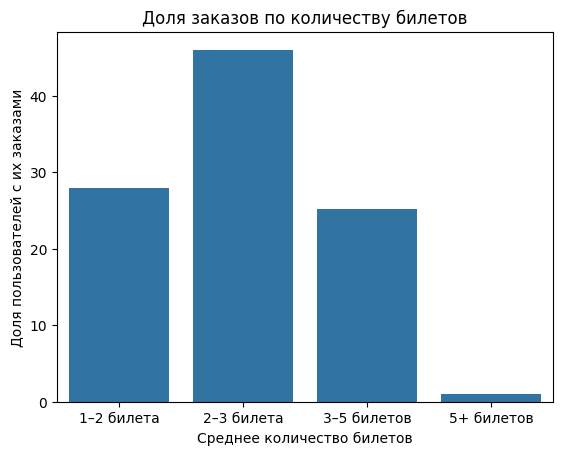

In [86]:
# построим диаграмму распределения в процентах заказов
sns.barplot(
    data=tickets_segments,
    x='tickets_segment',
    y='users_segment_perc'
)

plt.title('Доля заказов по количеству билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля пользователей с их заказами')

plt.show()

**Ответы на вопросы:** 
1) Как распределены пользователи по сегментам — равномерно или сконцентрировано?

Как и на графике немного выше видно, что в основном пользователи покупают 2-3 билета - 46.01%, 1-2 билета приобретают 27.9% пользователей и немногим меньше 3-5 билетов , что составляет 25.14% от всех заказов. Самые редкие слкчаи это покупки более 5 билетов - доля составляет менее 1% от общего количества.
 
2) Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

На мой взгляд аномалий в результатах нет.  

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [87]:
user_profile.head(10)

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five,tickets_segment
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0.000000,0,0,3–5 билетов
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37.500000,1,0,2–3 билета
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34.000000,1,0,2–3 билета
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0.000000,0,0,3–5 билетов
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8.000000,1,0,1–2 билета
5,000cf0659a9f40f,2024-06-20 10:35:26,2024-06-21 04:36:17,mobile,Широковская область,Лови билет!,концерты,13,1175.808462,3.307692,0.076923,1,1,3–5 билетов
6,00147c9209d45d3,2024-06-25 23:26:58,2024-06-25 23:28:52,mobile,Каменевский регион,Облачко,концерты,2,352.945000,1.500000,0.000000,1,0,1–2 билета
7,0018ecd8a38a51b,2024-07-25 20:38:57,2024-07-25 20:38:57,mobile,Медовская область,Билеты без проблем,спорт,1,0.000000,3.000000,0.000000,0,0,2–3 билета
8,00199a573901564,2024-06-17 22:58:15,2024-06-17 22:58:15,mobile,Каменевский регион,Билеты без проблем,концерты,1,588.120000,4.000000,0.000000,0,0,3–5 билетов
9,001e7037d013f0f,2024-07-04 08:06:44,2024-09-29 22:58:14,mobile,Златопольский округ,Мой билет,другое,3,326.623333,1.333333,29.000000,1,0,1–2 билета


In [88]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21932 entries, 0 to 21932
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21932 non-null  object        
 1   first_order_date  21932 non-null  datetime64[ns]
 2   last_order_date   21932 non-null  datetime64[ns]
 3   first_device      21932 non-null  object        
 4   first_region      21932 non-null  object        
 5   first_service     21932 non-null  object        
 6   first_event_type  21932 non-null  object        
 7   orders_count      21932 non-null  int64         
 8   avg_revenue_rub   21932 non-null  float64       
 9   avg_tickets       21932 non-null  float64       
 10  avg_days_between  21932 non-null  float64       
 11  is_two            21932 non-null  int64         
 12  is_five           21932 non-null  int64         
 13  tickets_segment   21932 non-null  category      
dtypes: category(1), datetime64[

In [89]:
# выделяем день недели отдельным столбцом
user_profile['weekday'] = user_profile['first_order_date'].dt.day_name()

In [90]:
# группировка по дням недели и подсчет общего числа пользователей и долю пользователей, совершивших повторные заказы. 
# Результаты визуализируйте
weekday_statistic = (
    user_profile
    .groupby('weekday')
    .agg(users_count=('user_id', 'count'))
    .reset_index())

# округлим и добавим проценты для вернувшихся пользователей
weekday_statistic['return_users_perc'] = (weekday_statistic['users_count'] / weekday_statistic['users_count'].sum() * 100).round(2)

# вывод данных
weekday_statistic

,weekday,users_count,return_users_perc
0,Friday,3274,14.93
1,Monday,2947,13.44
2,Saturday,3460,15.78
3,Sunday,2819,12.85
4,Thursday,3130,14.27
5,Tuesday,3218,14.67
6,Wednesday,3084,14.06


In [91]:
# сортировка дней недели по человечески
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_statistic['weekday'] = pd.Categorical(weekday_statistic['weekday'], categories=day_order, ordered=True)

weekday_statistic = weekday_statistic.sort_values('weekday')

weekday_statistic

,weekday,users_count,return_users_perc
1,Monday,2947,13.44
5,Tuesday,3218,14.67
6,Wednesday,3084,14.06
4,Thursday,3130,14.27
0,Friday,3274,14.93
2,Saturday,3460,15.78
3,Sunday,2819,12.85


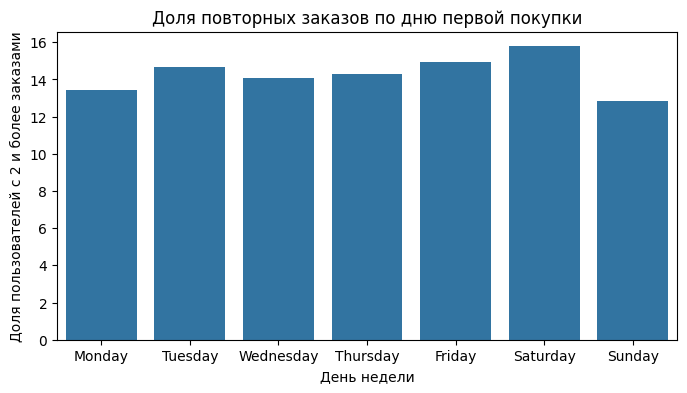

In [92]:
#
plt.figure(figsize=(8,4))

sns.barplot(
    data=weekday_statistic,
    x='weekday',
    y='return_users_perc'
)

plt.title('Доля повторных заказов по дню первой покупки')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с 2 и более заказами')

plt.show()

Вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?
Судя по процентному соотношению людей, вернувшихся брать билеты снова - день недели мало влияет на этот показатель, и в целом колеблется от 12 до 15%. 
Можно лишь сделать вывод, что чаще всего в субботу, когда у людей выходной они выбирают себе мероприятие и  заказ билетов. 


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [93]:
# подсчет среднего количества дней для 2-4 заказов
print(f"Средний интервал для 2-4 заказов: {users_2_4_orders['avg_days_between'].mean()}")

Средний интервал для 2-4 заказов: 12.455418237676302


In [94]:
users_2_4_orders['avg_days_between'].describe()

count    7161.000000
mean       12.455418
std        15.515632
min         0.000000
25%         0.000000
50%         5.500000
75%        21.250000
max        74.000000
Name: avg_days_between, dtype: float64

In [95]:
# подсчет среднего количества дней для >5 заказов
print(f"Средний интервал для 5 и более заказов: {users_5_plus_orders['avg_days_between'].mean()}")

Средний интервал для 5 и более заказов: 8.359128491920343


In [96]:
users_5_plus_orders['avg_days_between'].describe()

count    6397.000000
mean        8.359128
std         6.449587
min         0.000000
25%         3.250000
50%         7.100000
75%        12.142857
max        30.000000
Name: avg_days_between, dtype: float64

Судя по выводу выше, пользователи, у которых более 5 заказов промежуток между этими самыми заказами на треть (полных 4 дня) меньше, чем у тех, кто совершил 2-4 заказа. 
Помимо этого среднее отклонение у пользователей с большим количеством заказов значительно ниже, чем у заказывающих меньше. 

Это очень хорошие показатели, и имеет смысл предлагать таким пользователям (5+ заказов) дополнительные акции, скидки - улучшения для того, чтобы сохранить и увеличить их лояльность. 


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [97]:
# вывод первых 5 строк для напоминания, над чем именно работаю
user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five,tickets_segment,weekday
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,0.0,0,0,3–5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,37.5,1,0,2–3 билета,Tuesday
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,34.0,1,0,2–3 билета,Saturday
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,0.0,0,0,3–5 билетов,Thursday
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,8.0,1,0,1–2 билета,Sunday


In [98]:
# выделим столбцы для подсчета корреляции
corr_df = user_profile[[
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'orders_count']]

In [99]:
# используем параметр interval_cols для определения интервальных данных
interval_cols = ['orders_count','avg_revenue_rub','avg_tickets','avg_days_between']

In [100]:
# посчитаем матрицу корреляций
phik_corr = corr_df.phik_matrix(interval_cols=interval_cols)

phik_corr

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets,avg_days_between,orders_count
first_device,1.000000,0.116192,0.082735,0.061685,0.021677,0.057707,0.021817,0.000000
first_region,0.116192,1.000000,0.695745,0.510343,0.000000,0.111163,0.079090,0.215807
first_service,0.082735,0.695745,1.000000,0.587148,0.202823,0.154532,0.041904,0.113072
first_event_type,0.061685,0.510343,0.587148,1.000000,0.091744,0.081977,0.049654,0.000000
avg_revenue_rub,0.021677,0.000000,0.202823,0.091744,1.000000,0.519545,0.027226,0.000000
avg_tickets,0.057707,0.111163,0.154532,0.081977,0.519545,1.000000,0.210443,0.029058
avg_days_between,0.021817,0.079090,0.041904,0.049654,0.027226,0.210443,1.000000,0.000000
orders_count,0.000000,0.215807,0.113072,0.000000,0.000000,0.029058,0.000000,1.000000


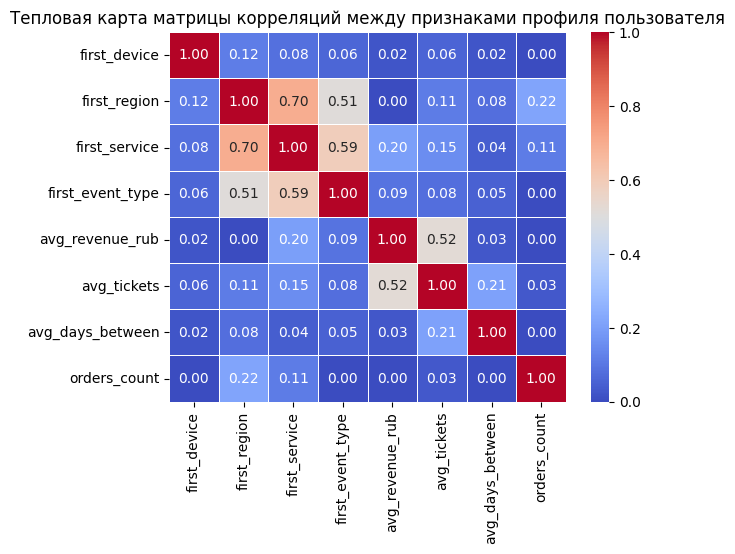

In [101]:
# построим тепловую карту
sns.heatmap(data=phik_corr, annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций между признаками профиля пользователя')
plt.show()

Выводы из матрицы корреляций: сильная взаимосвязь наблюдается между сервисом заказа `first_service` и регионом заказа `first_region` - 0.7, а также между сервисом `first_service` и типом мероприятия `first_event_type` - 0.59. 
То есть определенный сервис коррелирует больше всего с регионом, где он распрастранен и с типом мероприятия: некоторые сервисы предлагают билеты на определенные мероприятия лушче, или вызывают больше ассоциаций у пользователей. 

Умеренная, но ощутимая также между регионом `first_region` и типом мероприятия `first_event_type` - 0.51, а также между средней стоимостью `avg_revenue_rub` и количеством билетов `avg_tickets` - 0.52. 
Здесь также наблюдается взаимосвязь между регионом и типом мероприятия: видимо в некоторых регионах есть определенные более известные мероприятия, типа театров, концертов которые наиболее часто проходят. 
Касательно стоимости и количества билетов можно сказать: чем ниже цена, тем больше билетов пользователи могут приобрести. 

На остальные показатели на мой взгляд не стоит обращать внимания: если убрать самые большие заказы по билетам корреляция стремится к нулю по отношению ко всем остальным признакам, а связь между средним количеством билетов и средним количеством дней между заказами мало чего может показать. 

In [102]:
#(user_profile['orders_count'] > 2000).sum()

In [103]:
# этот датасет использован для личного исследования матрицы корреляций и очень незначительно отличался от user_profile
# user_profile_new = user_profile[user_profile['orders_count'] < 2000]

In [104]:
# разобьем на сегменты по числу заказов
user_profile['orders_segment'] = pd.cut(
    user_profile['orders_count'],
    bins=[1,2,5,user_profile['orders_count'].max()],
    labels=[
        '1 заказ',
        '2-4 заказа',
        '5 и более заказов'
    ],
    right=False
)

In [105]:
# выделим столбцы для подсчета корреляции с учетом разбития на сегменты
corr_df_segment = user_profile[[
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'orders_segment' # замена поля общего количества билетов на разделенное по сегментам 'orders_count'
]]

In [106]:
# используем параметр interval_cols для определения интервальных данных, без 'orders_count'
interval_cols = ['avg_revenue_rub','avg_tickets','avg_days_between']

In [107]:
# посчитаем матрицу корреляций
phik_corr_segment = corr_df_segment.phik_matrix(interval_cols=interval_cols)

phik_corr_segment

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets,avg_days_between,orders_segment
first_device,1.000000,0.116192,0.082735,0.061685,0.021677,0.057707,0.021817,0.016642
first_region,0.116192,1.000000,0.695745,0.510343,0.000000,0.111163,0.079090,0.125500
first_service,0.082735,0.695745,1.000000,0.587148,0.202823,0.154532,0.041904,0.081432
first_event_type,0.061685,0.510343,0.587148,1.000000,0.091744,0.081977,0.049654,0.041325
avg_revenue_rub,0.021677,0.000000,0.202823,0.091744,1.000000,0.519545,0.027226,0.081752
avg_tickets,0.057707,0.111163,0.154532,0.081977,0.519545,1.000000,0.210443,0.411764
avg_days_between,0.021817,0.079090,0.041904,0.049654,0.027226,0.210443,1.000000,0.592341
orders_segment,0.016642,0.125500,0.081432,0.041325,0.081752,0.411764,0.592341,1.000000


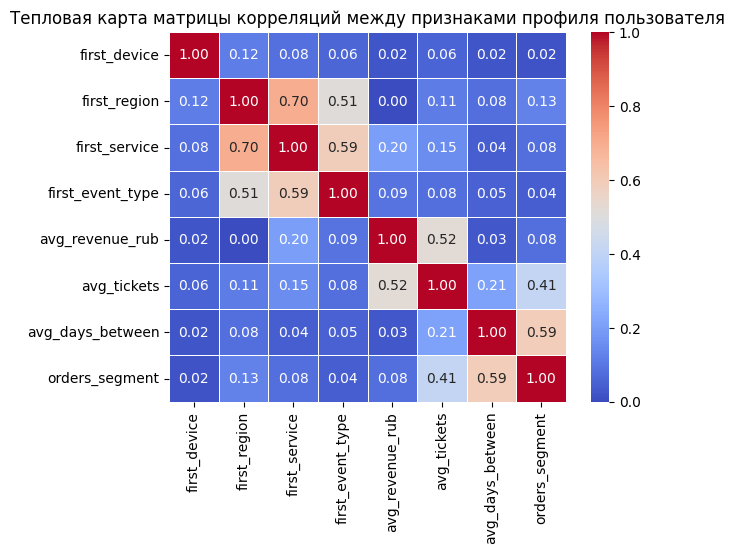

In [108]:
# построим тепловую карту  с учетом сегментов
sns.heatmap(data=phik_corr_segment, annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций между признаками профиля пользователя')
plt.show()

Вывод из графика с учетом разделения пользователей по сегментам и в сравнении с графиком корреляций выше: 

Такая же сильная взаимосвязь наблюдается между сервисом заказа `first_service` и регионом заказа `first_region` - 0.7, а также между сервисом `first_service` и типом мероприятия `first_event_type` - 0.59.  

Такие же данные, умеренная корреляция, также между регионом `first_region` и типом мероприятия `first_event_type` - 0.51, а также между средней стоимостью `avg_revenue_rub` и количеством билетов `avg_tickets` - 0.52. 

Из *явных изменений*: появление умеренной корреляции между сегментами `orders_segment` и средним количеством билетов `avg_tickets` - 0.41, однако мало какие выводы можно сделать из этой взаимосвязи. 
И появление умеренной корреляции между сегментами `orders_segment` и средним количеством дней между заказами `avg_days_between`. 

In [109]:
corr_df_1 = user_profile[user_profile['orders_segment'] == '1 заказ'][[
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets']]

In [110]:
phik_corr_1 = corr_df_1.phik_matrix(interval_cols=['avg_revenue_rub','avg_tickets'])

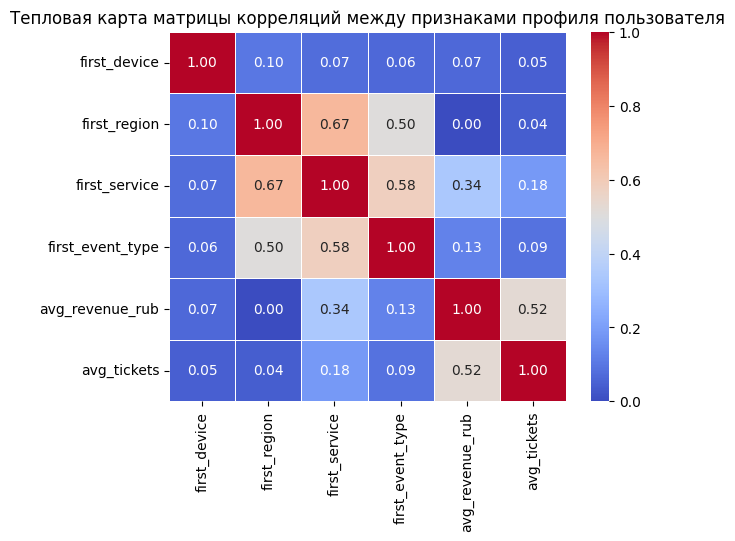

In [111]:
# построим тепловую карту  с учетом сегментов
sns.heatmap(data=phik_corr_1, annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций между признаками профиля пользователя')
plt.show()

В случае выбора по сегментам и в рамках только одного заказа можно увидеть, что появилась корреляция между количеством билетов и стоимостью - 0.52: выше была информация, что один заказ выполнялся чаще, когда стоимость билета на мероприятие была невысокой на сервисе. 
Поэтому также видно, что есть довольно низкая корреляция между стоимостью и типом сервиса для покупки. 

In [112]:
corr_df_2_4 = user_profile[user_profile['orders_segment'] == '2-4 заказа'][[
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between']]

In [113]:
phik_corr_2_4 = corr_df_2_4.phik_matrix(interval_cols=['avg_revenue_rub','avg_tickets','avg_days_between'])

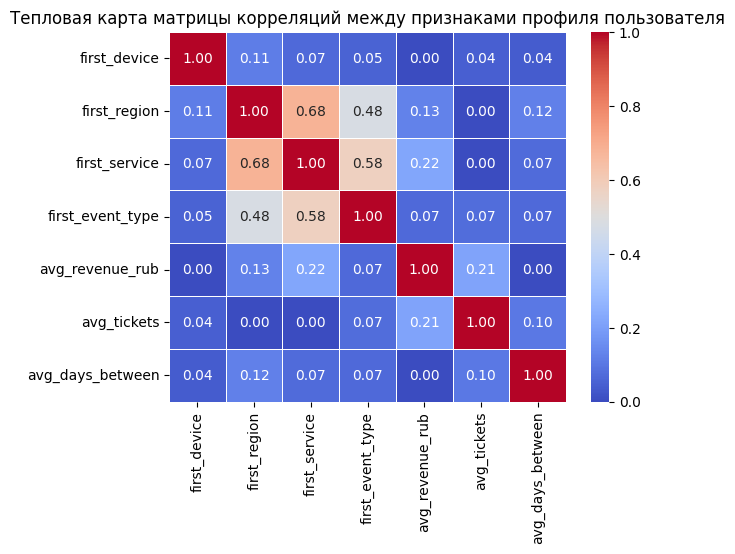

In [114]:
# построим тепловую карту  с учетом сегментов
sns.heatmap(data=phik_corr_2_4, annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций между признаками профиля пользователя')
plt.show()

В случае оформления 2-4 заказов корреляция между средним количеством потраченных средств и сервисом уменьшается до 0.22 и примерно до такой же цифры падает связь между средним количетсвом билетов в заказе и потраченнной суммой на них - 0.21.

In [115]:
corr_df_5 = user_profile[user_profile['orders_segment'] == '5 и более заказов'][[
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between']]

In [116]:
phik_corr_5 = corr_df_5.phik_matrix(interval_cols=['avg_revenue_rub','avg_tickets','avg_days_between'])

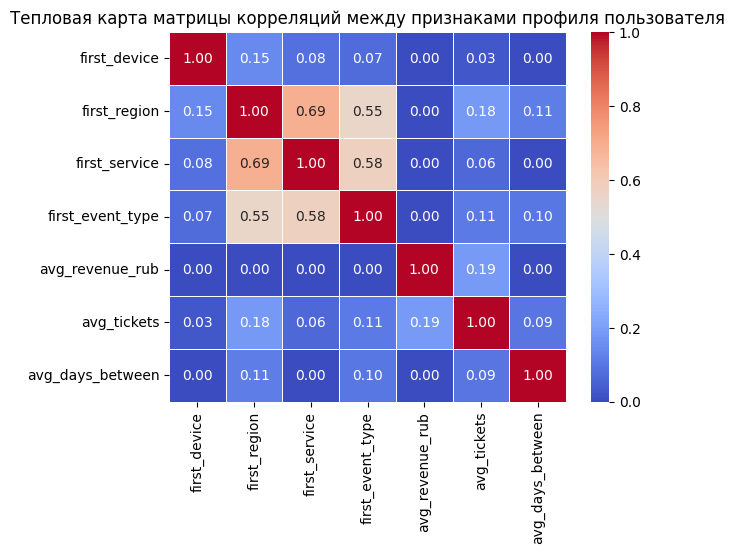

In [117]:
# построим тепловую карту  с учетом сегментов
sns.heatmap(data=phik_corr_5, annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций между признаками профиля пользователя')
plt.show()

В случае 5 и более заказов корреляция между количеством билетов, сервисом и стоиостью стремятся к нулю, и не имеют влияния. 

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

#### **Подготовка данных** 

В рамках проекта был проведён анализ поведения пользователей сервиса Яндекс Афиша для покупки билетов на мероприятия в разных городах. 
В работе использовались данные о заказах пользователей с информацией о дате покупки, стоиомсти заказов, количестве билетов, типах мероприятий, регионах, устройствах пользователей и билетном операторе. 

На этапе предобработки данных были проверены пропущенные значения и некоторые удалены, некоторые подлежали замене значений. 
Валют для оплаты было две - рубли и тенге, всё переведено в рубли в соответствии с курсом между этими валютами на день проведения операции. 
Были проанализированы выбросы в рамках общей стоимости заказов и экстемальные значения были отфильтрованы по 99 перцентилю, 
вследствие чего было удалено около 1 процента строк. 

На основе этих данных был сформирован профиль пользователя, в котором были отображены данные по первому заказу, 
средние показатели заказов и поведенческие характеристики (даты первого последнего закказов, промежуток времени между заказами, среднее количество билетов в заказе, первое устройство, с которого был совершен заказ и тд). 



#### **Основные результаты анализа** 

В выборке оказалось 21933 пользователя, с дополнительными полями характеристиками по количеству заказов: два и более, пять и более заказов. 
1) судя по диаграмме размаха количества заказов для каждого пользователя есть один сильно выдающийся, где количество заказов равно 10251. Поэтому для более обьективного анализа данных строка с этим показателем была удалена из выборки.
2) диаграмма размаха среднего количества билетов показала вариацию от 2 до 12 билетов, что вполне допустимо. 
3) в диаграмме размаха касательно среднего количества дней между заказами основная масса показателей лежит между 0 и 10 днями, а максимальное количество дней 74.

Средняя выручка с одного заказа: 574.02 

Доля пользователей, совершивших 2 и более заказа: 61.82% 

Доля пользователей, совершивших 5 и более заказов: 29.17%





Самый очевидный признак того, что пользователь **не** возвращается для покупки билетов снова - покупка одного билета и самого дешевого, либо в самом низком ценовом диапазоне. 

Однако в том случае, если количество билетов было от одного и больше и цена была выбрана не самая принципиально низкая - пользователь возвращался на сервис снова - в среднем покупается от 2 до 3 билетов, и средняя стоимость заказа составляет 574 рубля. 
Исходя из данных получено, что в основном пользователи покупают от 1 до 6 билетов, где средняя выручка заказа находится в рамках от 0 до 2500 рублей. 

Касательно временных характеристик и их влияния на удержание пользователей: 
По фактическим данным день недели мало влияет на этот показатель, однако больше всего пользователи покупали билеты по субботам (15.78%) и реже всего по воскресеньям (12.85%). 
Могу сделать вывод, что чаще всего в субботу, когда у людей выходной они выбирают себе мероприятие и  заказ билетов. 

Пользователи с более чем 5 заказами имеют промежуток между этими самыми заказами чуть больше 8 дней, в то время как те, кто совершил 2-4 заказа имеют промежуток немногим более 12 дней. Помимо этого среднее отклонение у пользователей с большим количеством заказов значительно ниже, чем у заказывающих меньше.

Это очень хорошие показатели, и имеет смысл предлагать таким пользователям (5+ заказов) дополнительные акции, скидки, улучшения - для того, чтобы сохранить и увеличить их лояльность.


Выводы из матрицы корреляций: сильная взаимосвязь наблюдается между сервисом заказа и регионом заказа - 0.7, а также между сервисом и типом мероприятия - 0.59. 
То есть определенный сервис коррелирует больше всего с регионом, где он распрастранен и с типом мероприятия: некоторые сервисы предлагают билеты на определенные мероприятия лушче, или вызывают больше ассоциаций у пользователей. 

Умеренная, но ощутимая также между регионом и типом мероприятия - 0.51, а также между средней стоимостью и количеством билетов - 0.52. 
Здесь также наблюдается взаимосвязь между регионом и типом мероприятия: видимо в некоторых регионах есть определенные более известные мероприятия, типа театров, концертов которые наиболее часто проходят. 
Касательно стоимости и количества билетов можно сказать: чем ниже цена, тем больше билетов пользователи могут приобрести. 

*Моя рекомендация* в этом случае будет следующей: сделать больше рекламы сервису по покупке билетов, как напоминание в виде email, контекстной рекламы о новых мероприятиях, ценах и всей важной информации, касающейся мероприятий. 
Проверить личный кабинет пользователя: логичный и структурированный интерфейс, где можно легко найти билеты и отправить на телефон например в виде pdf файлов, где есть архив данных с чеками, информацией о покупке. 
Важно делать дополнительные плюшки для пользователей, имеющих много заказов - скидки, специальные предложения в стиле "купи 5 билетов и получи 6й бесплатно", отправка этих предложений в конце рабочего дня, или во время обеда (примерное время большинства людей, работающих 5дневку). 


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**